# Session 3: Data Quality


## Learning goals

- Data Quality Dimensions
- Data Quality Checks
- Data Profiling
- Missing Values
    - Realistic Missingness Patterns
    - Imputation
- Outlier detection
- Redaction

## Why Data Quality

- Poor data quality costs the US economy **~$3.1 trillion/year** (IBM, 2016)
- ML models inherit and **amplify** data defects (Sculley et al., 2015 — *Hidden Technical Debt in ML Systems*, NeurIPS)
- GDPR, HIPAA and ISO 8000 mandate **measurable data quality standards**
- Data Quality is difficult to automate (@biessmann2021automated and @schelter2018automating)

| Aspect | GDPR (General Data Protection Regulation) | HIPAA (Health Insurance Portability and Accountability Act) |
| --- | --- | --- |
| Scope | Protects personal data of EU citizens, globally | Protects health information of US patients |
| Data Covered | Any personal data (name, email, IP, etc.) | Protected Health Information (PHI) only |
| Who Must Comply | Any organization processing EU residents’ data | US healthcare providers, insurers, and business associates |
| Key Rights | Right to access, correct, delete, and port data | Right to access, amend, and restrict PHI disclosure |
| Penalties | Up to 4% of global revenue or €20M, whichever is higher | Up to $1.5M per violation, per year |
| Breach Notification | Within 72 hours of discovery | Within 60 days of discovery |

## The 6 Core Dimensions (Wang & Strong, 1996)

| Dimension | Question |
|---|---|
| **Completeness** | Are all values present? |
| **Uniqueness** | Are records deduplicated? |
| **Consistency** | Do values obey rules/formats? |
| **Accuracy** | Do values reflect reality? |
| **Timeliness** | Is data current enough? |
| **Validity** | Do values match expected domains? |

@wang1996beyond

![ML in Academia](../figures/ML_Acad.png)

![ML in Production](../figures/ML_Prod.png)

adapted from @sculleyHiddenTechnicalDebt2015a

# Data Quality Monitoring

In [39]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

df = pd.DataFrame({
    'employee_id': list(range(1, n + 1)) + [5, 12],          # duplicates
    'name':        ['Alice', 'Bob'] * (n // 2) + [None, 'Bob'],
    'age':         np.random.randint(22, 65, n + 2).tolist(),
    'salary':      np.random.normal(55000, 12000, n + 2).tolist(),
    'department':  np.random.choice(['HR', 'Eng', 'Sales', None], n + 2).tolist(),
    'hire_date':   pd.date_range('2015-01-01', periods=n + 2, freq='W'),
})

# Inject outliers
df.loc[10, 'salary'] = 999_999
df.loc[20, 'age']    = -5

print(f'Shape: {df.shape}')
df.head(3)

Shape: (202, 6)


,employee_id,name,age,salary,department,hire_date
0,1,Alice,60,45378.065880,HR,2015-01-04
1,2,Bob,50,71608.188627,Sales,2015-01-11
2,3,Alice,36,71862.463671,HR,2015-01-18


## Automated Profiling with `ydata-profiling`

> Formerly known as `pandas-profiling` — generates a comprehensive HTML report covering all quality dimensions in one call.

**Reference:** Branco, P. et al. (2016). *A survey of predictive modelling under imbalanced distributions.* ACM CSUR — recommended pairing with profiling for imbalanced label detection.

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title='Employee Dataset Quality Report',
    explorative=True,
    minimal=False,
)

# Save to HTML for sharing
profile.to_file('data_quality_report.html')

# Render inline in the notebook
profile.to_notebook_iframe()

ModuleNotFoundError: No module named 'pkg_resources'

### Completeness

> *"Completeness: the degree to which all required data is present."*  
> — ISO/IEC 25012 (2008), Data Quality Model

**Metric:**  
$$\text{Completeness}(c) = 1 - \frac{|\text{NULL values in column } c|}{|\text{total rows}|}$$

=== Completeness per column ===
employee_id    1.000
name           0.995
age            1.000
salary         1.000
department     0.767
hire_date      1.000

Overall completeness: 96.04%


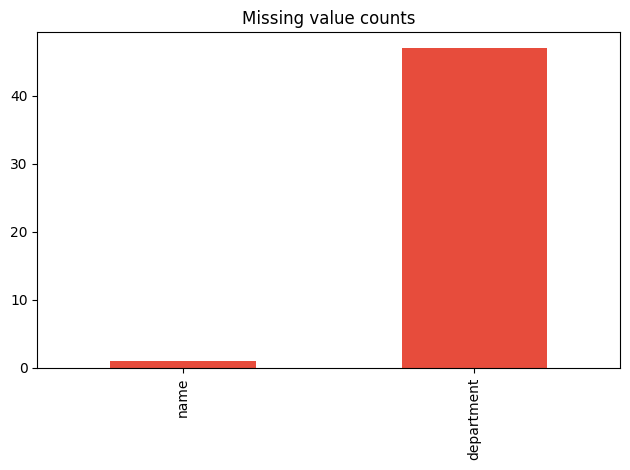

In [30]:
completeness = 1 - df.isnull().mean()

print('=== Completeness per column ===')
print(completeness.round(3).to_string())

print(f'\nOverall completeness: {completeness.mean():.2%}')

# Visualise missing pattern
import matplotlib.pyplot as plt
missing = df.isnull().sum()
missing[missing > 0].plot(kind='bar', color='#e74c3c', title='Missing value counts')
plt.tight_layout()
plt.show()

## Uniqueness / Duplicates

Duplicate records inflate model training data and distort statistics (Breck et al., 2017 — *The ML Test Score*, IEEE BigData).

**Metric:**  
$$\text{Uniqueness} = 1 - \frac{|\text{duplicate rows}|}{|\text{total rows}|}$$

In [31]:
n_dupes = df.duplicated(subset='employee_id').sum()
uniqueness = 1 - n_dupes / len(df)

print(f'Duplicate employee_id rows : {n_dupes}')
print(f'Uniqueness score           : {uniqueness:.2%}')

# Inspect
df[df.duplicated(subset='employee_id', keep=False)].sort_values('employee_id')

Duplicate employee_id rows : 2
Uniqueness score           : 99.01%


,employee_id,name,age,salary,department,hire_date
4,5,Alice,29,44432.310178,Eng,2015-02-01
200,5,None,32,64248.139954,Sales,2018-11-04
11,12,Bob,45,50613.528438,Sales,2015-03-22
201,12,Bob,38,63004.673242,HR,2018-11-11


## Validity & Consistency

Values must conform to **domain rules** and **referential constraints**.

Examples:
- `age` must be in `[18, 80]`
- `salary` must be `> 0`
- `department` must be in a known set

In [32]:
rules = {
    'age_valid':        df['age'].between(18, 80),
    'salary_positive':  df['salary'] > 0,
    'dept_known':       df['department'].isin(['HR', 'Eng', 'Sales']),
}

for rule_name, mask in rules.items():
    pass_rate = mask.mean()
    fail_count = (~mask).sum()
    print(f'{rule_name:<20} pass={pass_rate:.2%}  violations={fail_count}')

age_valid            pass=99.50%  violations=1
salary_positive      pass=100.00%  violations=0
dept_known           pass=76.73%  violations=47


## Declarative Data Quality Test

- Testing all data quality dimensions is difficult
- Some are easy to test
- Libraries provide declarative language to define tests
    - https://github.com/awslabs/deequ
    - https://github.com/great-expectations/great_expectations
- Defining tests remains manual work


```deequ```

```java 
val verificationResult = VerificationSuite()
    .onData(data)
    .addCheck(
        Check(CheckLevel.Error, "unit testing my data")
            .hasSize(_ == 5) // we expect 5 rows
            .isComplete("id") // should never be NULL
            .isUnique("id") // should not contain duplicates
            .isComplete("name") // should never be NULL
            // should only contain the values "high" and "low"
            .isContainedIn("priority", Array("high", "low"))
            // at least half of the descriptions should contain a url
            .containsURL("description", _ >= 0.5)
            // half of the items should have less than 10 views
            .hasApproxQuantile("numViews", 0.5, _ <= 10))
    .run()```

![dq-process.jpg](../figures/dq-process.jpg)

## `great_expectations`

Similar to deequ (Schelter et al) for Scala/Spark, the python library Great Expectations allows you to **define, document, and validate** data contracts declaratively.

Conceptually:
```
EXPECT column X TO HAVE values between A and B
EXPECT column Y TO NOT BE NULL
EXPECT table TO HAVE exactly N columns
```

In [33]:
import great_expectations as gx

context = gx.get_context(mode='ephemeral')
ds = context.sources.add_pandas('my_ds')
da = ds.add_dataframe_asset('employee_data')
batch = da.build_batch_request(dataframe=df)

suite = context.add_expectation_suite('employee_suite')
validator = context.get_validator(batch_request=batch, expectation_suite=suite)

# Define expectations
validator.expect_column_values_to_not_be_null('employee_id')
validator.expect_column_values_to_be_between('age', min_value=18, max_value=80)
validator.expect_column_values_to_be_in_set('department', ['HR', 'Eng', 'Sales'])
validator.expect_column_values_to_be_unique('employee_id')

results = validator.validate()
print(f'Success: {results.success}')
print(f'Passed: {results.statistics["successful_expectations"]} / '
      f'{results.statistics["evaluated_expectations"]}')

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/19 [00:00<?, ?it/s]

Success: False
Passed: 2 / 4


## Aggregated Quality Score

- Sometimes it can be helpful to aggregate data quality metrics
- @pipino2002data propose a composite score:

    $$\text{DQ Score} = \frac{1}{|D|} \sum_{d \in D} w_d \cdot m_d$$

    where $$w_d$$ is the weight for dimension $$d$$ and $$m_d \in [0, 1]$$ is its metric value.


In [37]:
scores = {
    'Completeness': completeness.mean(),
    'Uniqueness':   uniqueness,
    'Validity_age': df['age'].between(18, 80).mean(),
    'Validity_sal': (df['salary'] > 0).mean(),
    'Validity_dept': df['department'].isin(['HR','Eng','Sales']).mean(),
}

weights = [0.25, 0.25, 0.15, 0.15, 0.20]  # domain-defined
composite = sum(w * v for w, v in zip(weights, scores.values()))

print('--- Dimension Scores ---')
for k, v in scores.items():
    print(f'  {k:<20} {v:.2%}')
print(f'\n  Composite DQ Score   {composite:.2%}')

--- Dimension Scores ---
  Completeness         96.04%
  Uniqueness           99.01%
  Validity_age         99.50%
  Validity_sal         100.00%
  Validity_dept        76.73%

  Composite DQ Score   94.03%


## Accuracy / Outlier Detection

- The accuracy dimension of data quality refers to statistical properties of data
- Simple outlier detection: parametric tests (z-scoring)
- Statisticians / ML researchers develop anomaly / outlier detection methods 


# Anomaly Detection

* Anomaly detection is an important task
* Anomaly detection is **difficult**:
 * We usually don't know what is normal/anomalous
 * If we have examples of anomalies, they are usually *very rare*
* For evaluation, we can use *classification metrics* but we need labels for that

There are great libraries for anomaly detection:
* [scikit-learn anomaly detection demo](https://scikit-learn.org/stable/auto_examples/plot_anomaly_comparison.html#sphx-glr-auto-examples-plot-anomaly-comparison-py)
* [pyOD](https://github.com/yzhao062/pyod#quick-start-for-outlier-detection)

##  Simple Anomaly Detection
Statistical outliers can indicate **data entry errors** or **sensor faults**.

**Z-score method** (Iglewicz & Hoaglin, 1993):  
$$z_i = \frac{x_i - \bar{x}}{s} \quad \text{flag if } |z_i| > 3$$

**IQR method** (more robust to non-normal distributions):  
$$\text{flag if } x_i < Q_1 - 1.5 \cdot IQR \text{ or } x_i > Q_3 + 1.5 \cdot IQR$$

In [ ]:
from scipy import stats

for col in ['salary', 'age']:
    z = np.abs(stats.zscore(df[col].dropna()))
    out_idx = df[col].dropna().index[z > 3]
    print(f'[Z-score] {col} outliers ({len(out_idx)}):')
    print(df.loc[out_idx, ['employee_id', col]], '\n')

    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    iqr_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    print(f'[IQR]     {col} outliers: {iqr_mask.sum()}\n')

[Z-score] salary outliers (1):
    employee_id    salary
10           11  999999.0 

[IQR]     salary outliers: 1

[Z-score] age outliers (1):
    employee_id  age
20           21   -5 

[IQR]     age outliers: 1



## Another view: Tests using Parametric Distributions

Consider univariate data $x\in R^1$ drawn from a normal distribution $\mathcal{N}(\mu,\sigma^2)$.

In [ ]:
mu = 2
sigma = 3
x = np.random.randn(1000) * sigma + mu

plt.hist(x);

### What's an anomalous data point?

The likelihood of each sample under this distribution is given by 

$p(x) = {\frac {1}{\sigma {\sqrt {2\pi }}}}e^{-{\frac {1}{2}}\left({\frac {x-\mu }{\sigma }}\right)^{2}}$

So you can compute the likelihood of any given data point as:

In [ ]:
def gauss_likelihood(x, mu, sigma):
    '''
    Computes the likelihood of x assuming x is from a 
    normal distribution with mean mu and standard deviation sigma
    '''
    denom = (np.sqrt(2.*np.pi)*sigma)
    num = np.exp(-.5*((x - mu) / sigma)**2)
    return num/denom

print(gauss_likelihood(2., mu,sigma))

# alternatively you can use the scipy.stats package
from scipy.stats import norm
my_gauss = norm(mu, sigma)
print(my_gauss.pdf(2))

### Defining Anomaly

Given a data point and a (not necessarily generative) model of your data, you can define a threshold for *what's an anomaly*. 

For instance, a common threshold is to assume that data points for which $p(x)< 0.05$ or $p(x)< 0.01$ are anomalous.  

In [ ]:
steps = np.arange(-10,100)
plt.plot(x, gauss_likelihood(x,mu,sigma),'.');
plt.plot([-7.5,12.5],[.05,.05],'r--')
plt.plot([-7.5,12.5],[.01,.01],'k--')
plt.legend(['p(x)','0.05','0.01'])

## Multivariate Anomaly Detection

* Simple Parametric Approach: Assuming Gaussian Data
* Sophisticated Non-parametric: Isolation Forest

Example taken from [Alexandre Gramforts sklearn tutorial](https://scikit-learn.org/stable/auto_examples/plot_anomaly_comparison.html#sphx-glr-auto-examples-plot-anomaly-comparison-py)

In [40]:
from sklearn.datasets import make_moons, make_blobs
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest

plt.rcParams['contour.negative_linestyle'] = 'solid'
plt.rcParams['figure.figsize'] = [5, 5]

n_samples = 300
outliers_fraction = 0.15
n_outliers = int(outliers_fraction * n_samples)
n_inliers = n_samples - n_outliers

anomaly_algorithms = [
    ("Robust covariance", EllipticEnvelope(contamination=outliers_fraction)),
    ("Isolation Forest", IsolationForest(contamination=outliers_fraction,
                                         random_state=42))]

# Define datasets
blobs_params = dict(random_state=0, n_samples=n_inliers, n_features=2)
datasets = [
    make_blobs(centers=[[0, 0], [0, 0]], cluster_std=0.5,
               **blobs_params)[0],
    make_blobs(centers=[[2, 2], [-2, -2]], cluster_std=[0.5, 0.5],
               **blobs_params)[0],
    4. * (make_moons(n_samples=n_samples, noise=.05, random_state=0)[0] -
          np.array([0.5, 0.25]))]

# Compare given classifiers under given settings
xx, yy = np.meshgrid(np.linspace(-7, 7, 150),
                     np.linspace(-7, 7, 150))

plot_num = 1
rng = np.random.RandomState(42)


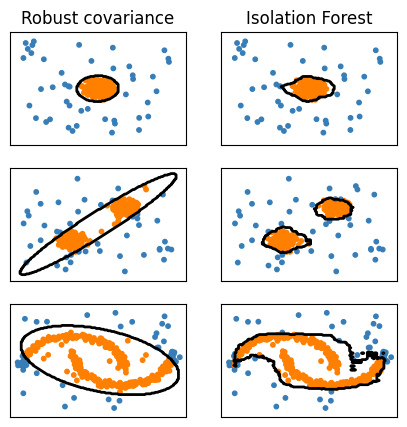

In [41]:
for i_dataset, X in enumerate(datasets):
    # Add outliers
    X = np.concatenate([X, rng.uniform(low=-6, high=6,
                       size=(n_outliers, 2))], axis=0)

    for name, algorithm in anomaly_algorithms:

        plt.subplot(len(datasets), len(anomaly_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=12)

        y_pred = algorithm.fit(X).predict(X)

        # plot the levels lines and the points
        Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')

        colors = np.array(['#377eb8', '#ff7f00'])
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[(y_pred + 1) // 2])

        plt.xlim(-7, 7)
        plt.ylim(-7, 7)
        plt.xticks(())
        plt.yticks(())
        plot_num += 1
        
plt.show()

# Missing Values



There are three main options how to deal with missing values:

- drop rows with missing values
    - probably ok, if you have enough data
    - but can introduce biases in your data that [bias your downstream models](http://arxiv.org/abs/1911.12587)
- replace missing values with placeholder symbol
    - probably ok, if you have a nonlinear downstream model and the right type of missingness (MAR or MNAR)
    - but sometimes you are really interested in the missing values
- impute missing values with some ML model
 



In [28]:
import pandas as pd
import numpy as np

berlin_population_dict = {
 '1945': 2807405,
 '1950': 3336026,
 '1955': None,                         
 '1960': 3274016,
 '1965': np.nan, # pandas understands different missing values                        
 '1970': 3208719}

population_w_nans = pd.Series(berlin_population_dict)
population_w_nans

1945    2807405.0
1950    3336026.0
1955          NaN
1960    3274016.0
1965          NaN
1970    3208719.0
dtype: float64

## Dropping rows

Easy with boolean indexing in pandas or numpy

In [2]:
population_w_nans.isnull()

1945    False
1950    False
1955     True
1960    False
1965     True
1970    False
dtype: bool

In [3]:
population_w_nans[~population_w_nans.isnull()]

1945    2807405.0
1950    3336026.0
1960    3274016.0
1970    3208719.0
dtype: float64

In [4]:
population_w_nans.dropna()

1945    2807405.0
1950    3336026.0
1960    3274016.0
1970    3208719.0
dtype: float64

## Filling with Placeholder


In [5]:
population_w_nans.fillna(method='ffill')

/var/folders/fb/nnrbj09j32jdr_jvd_fnmyn00000gn/T/ipykernel_82819/49778767.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  population_w_nans.fillna(method='ffill')


1945    2807405.0
1950    3336026.0
1955    3336026.0
1960    3274016.0
1965    3274016.0
1970    3208719.0
dtype: float64

In [6]:
population_w_nans.fillna(value=population_w_nans.median())

1945    2807405.0
1950    3336026.0
1955    3241367.5
1960    3274016.0
1965    3241367.5
1970    3208719.0
dtype: float64

## Filling with Placeholder in ``sklearn``

This way you'll be able to replace missing values in ML Pipelines

In [42]:
from sklearn.impute import SimpleImputer
import numpy as np
imp = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imp.fit_transform(population_w_nans.to_numpy().reshape(-1,1))

array([[2807405.],
       [3336026.],
       [2807405.],
       [3274016.],
       [2807405.],
       [3208719.]])

## Imputation

In [59]:
# some toy data with non-linear dependency between columns
n = 10
x = np.random.randn(n,1)
y = x**2

df = pd.DataFrame(np.hstack([x,y]),columns=['x','f(x)'])

mask = np.random.random((n,1)) > .9
df

,x,f(x)
0,1.176402,1.383921
1,-0.883131,0.779920
2,1.443284,2.083067
3,0.212655,0.045222
4,-0.071640,0.005132
5,-1.431801,2.050053
6,-1.109699,1.231432
7,0.350839,0.123088
8,-0.716808,0.513814
9,0.995053,0.990130


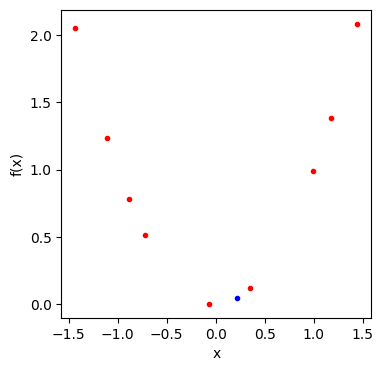

In [60]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pylab as plt

imp = IterativeImputer(max_iter=10, random_state=0)
X_train = df.loc[mask==0,:].values
imp.fit(X_train)

X_test = df.loc[mask>0,:].values
X_test_imputed = imp.transform(X_test)

plt.figure(figsize=[4,4])
plt.plot(X_train[:,0], X_train[:,1], 'r.',
         X_test_imputed[:,0], X_test_imputed[:,1],'b.')
plt.ylabel("f(x)")
plt.xlabel("x");

## This also works for Tabular Data
|Product| Description | Color|
|-------|--------------|---------|
|Shoe|Ideal for running| Black|
|Dress | This **yellow** dress ... | **?** | 
|...|...|...|

@biessmann2019datawig

# Privacy and redaction

- LLMs are popular 
- Privacy concerns with personally identifying information
- Named-Entity Recognition models can redact sensitive information
- [```redakto``` demo](https://redakto.demo.calgo-lab.de)